# Sensitivity Analysis
**Supporting Paper 1 (Applied Energy) and Paper 2 (Policy Studies Journal)**

---

## Purpose

This notebook runs two sweeps that address gaps flagged by MPSA discussants and co-author
review. Neither is a novel modelling contribution — they are robustness and characterisation
analyses that support claims already present in the draft.

### Sweep 1 — Uptake rate sweep (crossover curve)

Both targeting scenarios are run across a shared uptake rate axis (5%–80% in 5pp steps).
This produces the **crossover curve**: the uptake rate at which one strategy overtakes
another in citywide demand reduction. The curve answers the MPSA audience question:
*"at what scale does the equity-focused strategy become more efficient than the
consumption-focused one?"*

Three scenarios are included:
- `hp_top_users` — energy supplier targeting (Paper 1 baseline + Paper 2 unilateral)
- `hp_fuel_poverty` — local authority targeting (Paper 2 unilateral; **new**)
- `hp_social_rent` — tenure-based targeting (Paper 1 original comparison)

The Paper 2 crossover of interest is `hp_fuel_poverty` vs `hp_top_users`. The
`hp_social_rent` line is retained for Paper 1 continuity.

### Sweep 2 — Calibration parameter sensitivity (tornado chart)

The four key model calibration parameters are perturbed one-at-a-time (OAT) while all
others are held at their defaults. The metric is the **targeting advantage** — how much
more citywide demand reduction `hp_social_rent` achieves over `hp_top_users` at the
paper's assumed uptake rates (50% and 20% respectively). This is the 67% gap claimed in
§4.2 of the draft. The tornado chart shows whether that gap is stable across plausible
calibration assumptions.

**Paper 1 use:** Figures from both sweeps go in the sensitivity analysis section of Paper 1.
The crossover curve is also Figure 5 in Paper 2.

## Runtime

Both sweeps are expensive if run at full annual resolution. The default is **fast
annualization**: simulate a 28-day window and multiply by `365/28 ≈ 13.0` to get annual
equivalent. Results are cached to parquet/CSV so re-runs are instant.

Set `USE_FAST_ANNUALIZATION = False` before generating paper figures. Expect ~2–3 hours
on 8 cores for the full uptake sweep at annual resolution; the cal param sweep is faster
(only 9 configs × 2 scenarios rather than 16 rates × 3 scenarios).

All outputs land in `notebooks/results/sensitivity/`.

## Imports

- `itertools.product` — builds the Cartesian product of (uptake rates × scenarios × LSOAs)
  to generate the job list for the parallel pool
- `multiprocessing` — fork-based process pool; same pattern as `policy_scenarios_summary.ipynb`
- `tempfile` + `yaml` — each model run gets a temporary YAML config override written to disk
  and discarded after the run; this keeps the default config on disk untouched
- `household_energy.model.EnergyModel` — the MABM; see `household_energy/` for source

In [1]:
from __future__ import annotations

from itertools import product
from pathlib import Path
import multiprocessing as mp
import hashlib
import random
import tempfile
import warnings

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from household_energy.model import EnergyModel

warnings.filterwarnings('ignore', message='.*GeoSeries.notna.*')
warnings.filterwarnings('ignore', category=FutureWarning)

## 1) Settings

### Runtime parameters

**`USE_FAST_ANNUALIZATION`** — when `True`, the model runs for `WINDOW_DAYS × 24` hours
and the result is multiplied by `365 / WINDOW_DAYS` to estimate annual demand. This is a
defensible approximation for *comparative* analysis (the scaling factor is identical across
scenarios, so relative differences are preserved), but will slightly misrepresent seasonality
if the window falls entirely in winter or summer. A 28-day January window is roughly 10–15%
higher than the true annual mean for gas heating — accept this for exploration, correct it
for paper figures.

### Uptake rate sweep parameters

**`UPTAKE_RATES`** — 16 levels from 5% to 80% in 5pp steps. The range stops at 80% because
uptake above that is not credible for voluntary retrofit programmes in the UK; the SERL
benchmark and NCC targets both suggest 5–30% over a typical programme horizon.

**`PAPER_UPTAKE`** — the specific uptake rates assumed in the draft paper (50% for
`hp_social_rent`, 20% for `hp_top_users`). These are marked on the crossover figure with
vertical markers so the reader can see where the paper's headline result sits on the curve.

### Calibration parameter sweep parameters

**`CAL_PARAMS`** — OAT perturbations applied **relative to the calibrated value** read
from `CALIBRATED_CFG` at runtime, not hardcoded around textbook defaults. (The previous
version of this notebook used hardcoded `[0.04, 0.05, 0.06]` style ranges that didn't
match the actual calibrated values — see the `cal_sensitivity_raw.csv` legacy file.)

| Parameter | Targets | Kind | Range | Rationale |
|---|---|---|---|---|
| `heating_setpoint_C` | `heating_setpoint_C` | additive | ± 1.5 °C | spans SERL occupant survey IQR |
| `heating_slope_kWh_per_deg` | `heating_slope_kWh_per_deg` | multiplicative | × 0.80 – 1.20 | spans SAP HDD slope uncertainty |
| `baseline_anchors` | `baseline_anchor_elec_kwh_per_hour`, `baseline_anchor_gas_kwh_per_hour` | multiplicative | × 0.85 – 1.15 | spans SERL baseload P25–P75; both fuel anchors move together so the bar reflects "baseline level," not "fuel mix" |

**Dropped vs. the previous version:**
- `level_scale` — confirmed not wired to the YAML loader in `EnergyModel` (constructor
  kwarg only). Overriding it via config had no effect; the 0.2% deltas in the first run
  were stochastic noise.
- `baseline_anchor_kwh_per_hour` — shadowed by `use_separate_fuel_baseline_anchors=True`
  in the calibrated config. `agent.py` reads from the elec/gas anchors instead, so the
  override never took effect. We now perturb those two directly. Per-dwelling-type
  variation is preserved because `agent.py` multiplies each anchor by
  `property_type_mult_base` (and its electric/gas variants) at runtime.

The OAT design means we cannot detect interactions between parameters. A full factorial
design over three parameters at three levels would require 27 configs × 2 scenarios
rather than 7 × 2 — roughly 4× more compute. OAT is standard for ABM sensitivity
analysis at this scale (see Saltelli et al. 2004 for the full theory).

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

GEOJSON      = ROOT / 'data' / 'epc_abm_newcastle.geojson'
CLIMATE_FULL = ROOT / 'data' / 'ncc_2t_timeseries_2010_2039.parquet'
HIDP_CSV     = ROOT / 'data' / 'hidp_uprn_matches_tiered.csv'
OUTDIR       = ROOT / 'notebooks' / 'results' / 'sensitivity'
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Runtime ──────────────────────────────────────────────────────────────────
# True  → 28-day Jan window × 13.04 annualization (fast, biased high on heating)
# False → full 365-day simulation (paper-quality; ~13× longer)
USE_FAST_ANNUALIZATION = False
WINDOW_DAYS = 28
START_UTC   = '2023-01-01T00:00:00Z'
N_PROCS     = max(1, min(8, (mp.cpu_count() or 2) - 1))

WINDOW_HOURS  = (WINDOW_DAYS * 24) if USE_FAST_ANNUALIZATION else (365 * 24)
ANNUAL_FACTOR = (365.0 / WINDOW_DAYS) if USE_FAST_ANNUALIZATION else 1.0

# ── Climate slice ────────────────────────────────────────────────────────────
# The full climate parquet covers 2020–2039 hourly for every grid point — every
# worker that re-reads it pays ~30× the memory it actually uses. We slice once
# to [START_UTC − 48h, START_UTC + WINDOW_HOURS + 48h], cache it, and point
# CLIMATE at the slice. Auto-adapts when USE_FAST_ANNUALIZATION flips: a full
# annual run loads ~1 year instead of 20.
_buf_hours = 48
_slice_tag = f'{pd.Timestamp(START_UTC).strftime("%Y%m%d")}_{WINDOW_HOURS}h'
CLIMATE = OUTDIR / f'climate_slice_{_slice_tag}.parquet'

if not CLIMATE.exists():
    print(f'Building climate slice → {CLIMATE.name} ...', end=' ', flush=True)
    _start = pd.Timestamp(START_UTC) - pd.Timedelta(hours=_buf_hours)
    _end   = pd.Timestamp(START_UTC) + pd.Timedelta(hours=WINDOW_HOURS + _buf_hours)
    _full  = pd.read_parquet(CLIMATE_FULL)
    _mask  = (_full['timestamp'] >= _start) & (_full['timestamp'] <= _end)
    _full.loc[_mask].reset_index(drop=True).to_parquet(CLIMATE, index=False)
    del _full
    print('done.')

# ── Uptake rate sweep ─────────────────────────────────────────────────────────
UPTAKE_RATES = [round(r, 2) for r in np.arange(0.05, 0.81, 0.05)]

# Uptake rates used in the paper (§4.2 of the draft) — marked on the figure
PAPER_UPTAKE = {'hp_social_rent': 0.50, 'hp_top_users': 0.20}

# Scenarios in the uptake sweep (three lines on the crossover figure)
SWEEP_SCENARIOS = ('hp_top_users', 'hp_fuel_poverty', 'hp_social_rent')

# Scenarios in the calibration sensitivity sweep (Paper 1 claim: §4.2 gap)
CAL_SCENARIOS = ('hp_social_rent', 'hp_top_users')

# ── Calibration parameter sweep (one-at-a-time) ───────────────────────────────
# Perturbations are RELATIVE TO THE CALIBRATED VALUE (read at runtime from
# CALIBRATED_CFG), not against hardcoded defaults. The previous version assumed
# the "default" was 18.5°C / 0.05 kWh·°C⁻¹·h⁻¹; calibration actually lands at
# 13.0°C / 0.21, so the old ranges compared wildly off-calibration runs against
# the calibrated baseline and the tornado was meaningless.
#
# kind='add' → cal_value + offset (absolute, in the parameter's units)
# kind='mul' → cal_value × multiplier (dimensionless)
# targets    → list of config keys to move together (e.g. elec + gas anchors
#              shift in lockstep so the tornado bar reflects "baseline level",
#              not "elec-vs-gas mix")
#
# Dropped from the previous version:
#   level_scale          — not wired to the YAML loader in EnergyModel
#                          (constructor kwarg only; config override is ignored)
#   baseline_anchor_kwh  — shadowed by use_separate_fuel_baseline_anchors=True
#                          in the calibrated config; we now perturb the elec
#                          and gas anchors directly. Per-dwelling-type
#                          differentiation already flows through these via
#                          property_type_mult_base in agent.py.
CAL_PARAMS = {
    'heating_setpoint_C': {
        'kind':    'add',
        'lo':      -1.5,      # cal − 1.5 °C
        'hi':      +1.5,      # cal + 1.5 °C
        'targets': ['heating_setpoint_C'],
    },
    'heating_slope_kWh_per_deg': {
        'kind':    'mul',
        'lo':      0.80,      # cal × 0.80
        'hi':      1.20,      # cal × 1.20
        'targets': ['heating_slope_kWh_per_deg'],
    },
    'baseline_anchors': {
        'kind':    'mul',
        'lo':      0.85,
        'hi':      1.15,
        'targets': ['baseline_anchor_elec_kwh_per_hour',
                    'baseline_anchor_gas_kwh_per_hour'],
    },
}
CAL_PARAM_LABELS = {
    'heating_setpoint_C':        'Setpoint (°C, ±1.5)',
    'heating_slope_kWh_per_deg': 'Heating slope (±20%)',
    'baseline_anchors':          'Baseline anchors, elec+gas (±15%)',
}

# ── Aesthetics ────────────────────────────────────────────────────────────────
BLUE   = '#4c78a8'
ORANGE = '#f58518'
RED    = '#e45756'
GREEN  = '#54a24b'
GRAY_M = '#9e9e9e'

SCENARIO_COLORS = {
    'hp_top_users':    BLUE,
    'hp_fuel_poverty': GREEN,
    'hp_social_rent':  RED,
}
SCENARIO_LABELS = {
    'hp_top_users':    'Top-user targeting (energy supplier)',
    'hp_fuel_poverty': 'Fuel-poverty targeting (local authority)',
    'hp_social_rent':  'Social-rent targeting',
}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.7,
    'axes.titleweight':  'bold',
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   9,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'figure.dpi':        100,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
})

n_uptake_jobs = len(UPTAKE_RATES) * len(SWEEP_SCENARIOS)
n_cal_jobs    = (len(CAL_PARAMS) * 2 + 1) * len(CAL_SCENARIOS)
print(f'Root:              {ROOT}')
print(f'Output dir:        {OUTDIR}')
print(f'Climate slice:     {CLIMATE.name}')
print(f'Workers:           {N_PROCS} (maxtasksperchild=1)')
print(f'Window:            {WINDOW_HOURS}h  (annualization ×{ANNUAL_FACTOR:.2f})  '
      f'{"FAST 28-day" if USE_FAST_ANNUALIZATION else "FULL ANNUAL"}')
print(f'Uptake sweep:      {len(UPTAKE_RATES)} rates × {len(SWEEP_SCENARIOS)} scenarios = {n_uptake_jobs} city-level runs')
print(f'Cal param sweep:   {len(CAL_PARAMS) * 2 + 1} configs × {len(CAL_SCENARIOS)} scenarios = {n_cal_jobs} city-level runs')

# ── Calibration auto-pickup ──────────────────────────────────────────────────
# Find newest results/calibration_<timestamp>/calibrated_config.yaml and use it
# as the base config for every EnergyModel run. Scenario-specific overrides
# (e.g. heatpump_adoption_rate) are deep-merged on top below.
_cal_dirs = sorted((ROOT / 'results').glob('calibration_*'), key=lambda p: p.name)
if not _cal_dirs:
    raise FileNotFoundError(f"No calibration_* directory under {ROOT / 'results'}")
CAL_DIR = _cal_dirs[-1]
CAL_YAML = CAL_DIR / 'calibrated_config.yaml'
if not CAL_YAML.exists():
    raise FileNotFoundError(f"Calibrated config not found: {CAL_YAML}")
with CAL_YAML.open() as _f:
    CALIBRATED_CFG: dict = yaml.safe_load(_f) or {}
print(f'Calibration base:  {CAL_DIR.name}')


def _deep_merge(base: dict, override: dict) -> dict:
    """Recursive dict merge (override wins on conflict)."""
    out = dict(base)
    for k, v in (override or {}).items():
        if isinstance(v, dict) and isinstance(out.get(k), dict):
            out[k] = _deep_merge(out[k], v)
        else:
            out[k] = v
    return out


def _build_cal_override(spec: dict, level: str) -> dict:
    """Build a {'model': {...}} override from a CAL_PARAMS spec + level.

    Reads each target's calibrated value from CALIBRATED_CFG and applies the
    perturbation (additive or multiplicative). Targets in the same spec move in
    lockstep — useful when several keys represent a single conceptual parameter
    (e.g. elec + gas baseline anchors → "baseline level").
    """
    delta = spec['lo'] if level == 'low' else spec['hi']
    model_block: dict = {}
    cal_model = (CALIBRATED_CFG.get('model') or {})
    for key in spec['targets']:
        if key not in cal_model:
            raise KeyError(
                f"Calibrated config has no '{key}' to perturb. "
                f"Available keys (first 10): {sorted(cal_model.keys())[:10]}"
            )
        cal_val = float(cal_model[key])
        if spec['kind'] == 'add':
            model_block[key] = cal_val + delta
        elif spec['kind'] == 'mul':
            model_block[key] = cal_val * delta
        else:
            raise ValueError(f"Unknown perturbation kind: {spec['kind']}")
    return {'model': model_block}


# Audit print: show calibrated value + perturbed values for every target
print('\nPerturbations (relative to calibrated values):')
for pname, pspec in CAL_PARAMS.items():
    for target in pspec['targets']:
        cal_val = float(CALIBRATED_CFG['model'][target])
        if pspec['kind'] == 'add':
            lo_val = cal_val + pspec['lo']
            hi_val = cal_val + pspec['hi']
        else:
            lo_val = cal_val * pspec['lo']
            hi_val = cal_val * pspec['hi']
        print(f"  {pname:24s} {target:42s} cal={cal_val:.4f}  lo={lo_val:.4f}  hi={hi_val:.4f}")


Building climate slice → climate_slice_20230101_8760h.parquet ... done.
Root:              /Users/abeltran/Documents/GitHub/spdt_abm
Output dir:        /Users/abeltran/Documents/GitHub/spdt_abm/notebooks/results/sensitivity
Climate slice:     climate_slice_20230101_8760h.parquet
Workers:           8 (maxtasksperchild=1)
Window:            8760h  (annualization ×1.00)  FULL ANNUAL
Uptake sweep:      16 rates × 3 scenarios = 48 city-level runs
Cal param sweep:   7 configs × 2 scenarios = 14 city-level runs
Calibration base:  calibration_20260511_151920

Perturbations (relative to calibrated values):
  heating_setpoint_C       heating_setpoint_C                         cal=13.0000  lo=11.5000  hi=14.5000
  heating_slope_kWh_per_deg heating_slope_kWh_per_deg                  cal=0.2097  lo=0.1677  hi=0.2516
  baseline_anchors         baseline_anchor_elec_kwh_per_hour          cal=0.2905  lo=0.2470  hi=0.3341
  baseline_anchors         baseline_anchor_gas_kwh_per_hour           cal=0.2886  

## 2) Load and prepare synthetic population

### Data sources

Same two-file merge as `paper2_policy_scenarios.ipynb`:
- **GeoJSON** (`epc_abm_newcastle.geojson`): EPC-derived attributes per UPRN — `sap_band_ord`,
  `floor_area_m2`, `energy_cal_kwh` (calibrated baseline demand)
- **HIDP CSV** (`hidp_uprn_matches_tiered.csv`): sociodemographic match —  `tenure`,
  `hh_income_band`, `schedule_type`

### Eligible cohort masks

Three masks are defined — one per scenario:

**`hp_top_users`**: top 10% of dwellings by calibrated annual demand (`energy_cal_kwh`).
The 10% threshold is the eligible pool; the uptake rate then determines how many of those
9,771 homes actually receive a heat pump in each run. This mirrors the definition in
`policy_scenarios_summary.ipynb` exactly — the crossover curve must be consistent with the
paper's scenario definitions.

**`hp_fuel_poverty`**: EPC band E/F/G (`sap_band_ord ≤ 3`) AND bottom 2 income quintiles
(`hh_income_band` in `q1_lowest`, `q2_low`). This is the Warm Homes Plan eligibility
criterion. Within the eligible pool, the uptake rate selects homes ranked by consumption
(highest first) — the assumption is that the LA prioritises homes where the heat pump
saves most, given the equity constraint is already satisfied by the eligibility filter.

**`hp_social_rent`**: all social-rent tenancies, regardless of consumption or EPC.
Retained for Paper 1 continuity (the 67% gap in §4.2 of the draft compares this scenario
against `hp_top_users`).

### LSOA parquet cache

The GeoDataFrame is split into one parquet per LSOA shard. Each parallel worker reads
only its own shard, avoiding serialisation of the full GDF across process boundaries.
Parquets are only written if they don't already exist.

In [3]:
def load_enriched_gdf(geojson_path: Path, hidp_csv_path: Path | None) -> gpd.GeoDataFrame:
    g = gpd.read_file(geojson_path)
    g['UPRN'] = g['UPRN'].astype(str).str.strip()
    if hidp_csv_path and hidp_csv_path.exists():
        hidp = pd.read_csv(hidp_csv_path, low_memory=False)
        hidp.columns = [c.strip() for c in hidp.columns]
        hidp['uprn_chr'] = hidp['uprn_chr'].astype(str).str.strip()
        hidp = hidp.drop_duplicates(subset=['uprn_chr'])
        g = g.merge(hidp, how='left', left_on='UPRN', right_on='uprn_chr',
                    suffixes=('_geo', '_hidp'))
        for base in ['lsoa_code', 'ward_code']:
            geo_col, hidp_col = f'{base}_geo', f'{base}_hidp'
            if base not in g.columns:
                if geo_col in g.columns and hidp_col in g.columns:
                    g[base] = g[geo_col].combine_first(g[hidp_col])
                elif geo_col in g.columns:
                    g[base] = g[geo_col]
                elif hidp_col in g.columns:
                    g[base] = g[hidp_col]
    return g


def to_wgs84_points(gdf_in: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    g = gdf_in.dropna(subset=['geometry']).copy()
    g = g.to_crs(4326) if g.crs else g.set_crs(4326)
    if (g.geometry.geom_type != 'Point').any():
        g['geometry'] = g.geometry.centroid
    return g


gdf_all = load_enriched_gdf(GEOJSON, HIDP_CSV if HIDP_CSV.exists() else None)
gdf_all = to_wgs84_points(gdf_all)
gdf_all['AgentID'] = gdf_all['UPRN'].astype(str)

# Consumption ranking (used to select within eligible pools)
ranking = pd.to_numeric(
    gdf_all.get('energy_cal_kwh', gdf_all.get('floor_area_m2', 0)),
    errors='coerce',
).fillna(0.0)

# Top 10% by consumption (hp_top_users eligible pool)
cut = max(int(len(gdf_all) * 0.10), 1)
top_users_ids = set(gdf_all.loc[ranking.nlargest(cut).index, 'AgentID'].astype(str))

# EPC vulnerability and income band (hp_fuel_poverty eligible pool)
epc_ord  = pd.to_numeric(gdf_all.get('sap_band_ord', 4), errors='coerce').fillna(4)
inc_band = gdf_all.get('hh_income_band', pd.Series('', index=gdf_all.index)).astype(str)

ELIGIBLE_MASKS = {
    'hp_top_users':    gdf_all['AgentID'].isin(top_users_ids),
    'hp_fuel_poverty': epc_ord.le(3) & inc_band.isin(['q1_lowest', 'q2_low']),
    'hp_social_rent':  gdf_all.get('tenure', pd.Series('', index=gdf_all.index))
                              .astype(str).str.lower().eq('social_rent'),
}
ELIGIBLE_SIZES = {k: int(v.fillna(False).sum()) for k, v in ELIGIBLE_MASKS.items()}

# LSOA shards
PROCESS_COLUMN = 'lsoa_code' if 'lsoa_code' in gdf_all.columns else 'ward_code'
LSOA_UNITS = (
    gdf_all[PROCESS_COLUMN].astype(str)
    .replace('', np.nan).dropna().unique().tolist()
)

UNIT_INPUT_DIR = OUTDIR / 'unit_inputs'
UNIT_INPUT_DIR.mkdir(exist_ok=True)
written = 0
for unit in LSOA_UNITS:
    fpath = UNIT_INPUT_DIR / f'{PROCESS_COLUMN}={unit}.parquet'
    if not fpath.exists():
        gdf_all[gdf_all[PROCESS_COLUMN].astype(str) == unit].to_parquet(fpath, index=False)
        written += 1

print(f'City:              {len(gdf_all):,} dwellings | {len(LSOA_UNITS)} LSOAs')
print(f'Parquets:          {written} newly written')
print('Eligible pool sizes:')
for s, n in ELIGIBLE_SIZES.items():
    print(f'  {s:25s}: {n:,} ({n/len(gdf_all)*100:.1f}% of stock)')

City:              97,714 dwellings | 185 LSOAs
Parquets:          0 newly written
Eligible pool sizes:
  hp_top_users             : 9,771 (10.0% of stock)
  hp_fuel_poverty          : 2,697 (2.8% of stock)
  hp_social_rent           : 23,540 (24.1% of stock)


## 3) Model runner

### Design: two-pass, per-LSOA

`_run_lsoa` runs both a baseline and a policy simulation for a single LSOA at a single
uptake rate. It returns the annualized demand saving (GWh/yr equivalent). The function
is called for every (LSOA × scenario × uptake rate) combination in the sweep.

**Why simulate at LSOA level rather than city level?**
The LSOA-shard pattern allows parallel execution across ~185 independent shards. Each
shard is small enough to fit in memory on a single core. The city-level aggregate is
computed by summing LSOA results after all workers complete.

**Why run baseline and policy in the same function?**
For the uptake sweep, the baseline must be consistent with the policy run (same LSOA,
same random seed, same start date). Running both in the same worker ensures this.
It also means the cache (parquet of raw results) contains net savings, not raw demand
figures — the baseline is only needed as a reference point.

**Seed construction**
The seed is derived deterministically from the (LSOA, scenario, uptake rate, config)
tuple. This ensures:
- Re-runs produce identical results
- Different (LSOA, rate) combinations get independent seeds
- Scenario comparisons at the same uptake rate use different seeds (the scenario name
  is part of the seed), avoiding correlation artefacts

**Selection within eligible pool**
At each uptake rate, `n_take = floor(eligible_size × uptake_rate)` homes are selected.
Selection is by consumption rank (highest first) within the eligible pool. This is
consistent with the paper's assumption that programmes prioritise homes where the heat
pump saves the most, given whatever eligibility filter applies. For `hp_fuel_poverty`,
this means: within EPC E/F/G + Q1/Q2, pick the highest consumers first.

**`_build_and_run`** instantiates and steps the EnergyModel for `WINDOW_HOURS` steps,
then sums `annual_kwh_by_year` across all household agents. The YAML config override is
written to a temp file (rather than modifying the on-disk default) so runs are isolated.

**`_run_lsoa_star`** is the picklable wrapper for `pool.map` — `pool.starmap` doesn't
handle keyword arguments, so we pack the positional and keyword args into a single
tuple and unpack inside the wrapper.

In [4]:
def _build_and_run(gdf_in: gpd.GeoDataFrame, cfg_dict: dict | None) -> float:
    """Instantiate EnergyModel, run WINDOW_HOURS steps, return total kWh for window."""
    merged = _deep_merge(CALIBRATED_CFG, cfg_dict or {})
    with tempfile.NamedTemporaryFile('w', suffix='.yaml', delete=False) as tmp:
        yaml.safe_dump(merged, tmp)
        cfg_path = tmp.name

    m = EnergyModel(
        gdf=gdf_in,
        climate_parquet=str(CLIMATE),
        climate_start=START_UTC,
        collect_agent_level=False,
        agent_collect_every=168,
        config_path=cfg_path,
    )
    for _ in range(WINDOW_HOURS):
        m.step()

    return float(sum(
        sum((getattr(h, 'annual_kwh_by_year', {}) or {}).values())
        for h in m.household_agents
    ))


def _run_lsoa(
    unit_val: str,
    *,
    scenario: str,
    uptake_rate: float,
    cfg_override: dict | None = None,
) -> dict:
    """
    Run baseline + policy for one LSOA at one uptake rate.
    Returns annualized demand saving (kWh/yr, positive = energy saved).
    """
    g = gpd.read_parquet(UNIT_INPUT_DIR / f'{PROCESS_COLUMN}={unit_val}.parquet')
    g['AgentID'] = g['UPRN'].astype(str)

    seed_key = f'{unit_val}|{scenario}|{uptake_rate}|{cfg_override!r}'.encode()
    seed = int.from_bytes(hashlib.sha256(seed_key).digest()[:4], 'big')
    np.random.seed(seed)
    random.seed(seed)

    # Baseline: no heat pumps
    cfg_base: dict = {**(cfg_override or {})}
    cfg_base.setdefault('meta', {})['name']              = 'baseline'
    cfg_base.setdefault('model', {})['heatpump_adoption_rate'] = 0.0
    kwh_base = _build_and_run(g, cfg_base)

    # Select treated homes within this LSOA
    eligible_mask = ELIGIBLE_MASKS[scenario].reindex(g.index, fill_value=False)
    eligible_idx  = g.index[eligible_mask]
    n_take = int(np.floor(len(eligible_idx) * uptake_rate))

    if n_take == 0:
        return {
            'unit': unit_val, 'scenario': scenario,
            'uptake_rate': uptake_rate, 'saving_kwh_yr': 0.0, 'n_treated': 0,
        }

    # Rank within eligible pool by consumption; take top n_take
    rank_local   = ranking.reindex(g.index, fill_value=0.0)
    selected_idx = rank_local.loc[eligible_idx].nlargest(n_take).index

    g_pol = g.copy()
    g_pol['is_heatpump_candidate'] = 0
    g_pol.loc[selected_idx, 'is_heatpump_candidate']    = 1
    g_pol.loc[selected_idx, 'heatpump_candidate_class'] = 'priority'

    cfg_pol: dict = {**(cfg_override or {})}
    cfg_pol.setdefault('meta', {})['name']              = scenario
    cfg_pol.setdefault('model', {})['heatpump_adoption_rate'] = 1.0
    kwh_pol = _build_and_run(g_pol, cfg_pol)

    return {
        'unit': unit_val, 'scenario': scenario, 'uptake_rate': uptake_rate,
        'saving_kwh_yr': (kwh_base - kwh_pol) * ANNUAL_FACTOR,
        'n_treated': n_take,
    }


def _run_lsoa_star(args: tuple) -> dict:
    """Picklable wrapper: unpack (positional_tuple, kwargs_dict) for pool.map."""
    return _run_lsoa(*args[0], **args[1])


def _run_parallel(jobs, n_procs: int):
    """Run _run_lsoa_star over jobs using fork-based multiprocessing; fall back to serial on failure.

    ``maxtasksperchild=1`` recycles each worker after one LSOA so any per-run
    allocations (model state, climate dataframe in the EnergyModel) are released
    back to the OS instead of accumulating across the sweep.
    """
    if n_procs <= 1 or not jobs:
        return [_run_lsoa_star(j) for j in jobs]
    try:
        ctx = mp.get_context('fork')
        with ctx.Pool(processes=n_procs, maxtasksperchild=1) as pool:
            return pool.map(_run_lsoa_star, jobs)
    except Exception as e:
        print(f'Parallel pool failed ({e}); falling back to serial.')
        return [_run_lsoa_star(j) for j in jobs]


## 4) Uptake rate sweep

Runs all three scenarios across all uptake rates. The job list is the Cartesian product
of (uptake rates × scenarios × LSOAs). With 16 rates × 3 scenarios × 185 LSOAs,
the total is 8,880 LSOA-level runs — each requiring one baseline and one policy simulation.

### Caching

Results are cached to `uptake_sweep_raw.parquet`. The cache is checked for completeness:
if all three scenarios and all uptake rates are present, the sweep is skipped. If the
cache exists but was built with only the original two scenarios (`hp_social_rent` and
`hp_top_users`), `hp_fuel_poverty` runs will be computed and appended.

### Output structure

The raw output has one row per (LSOA × scenario × uptake rate) with columns:
`unit`, `scenario`, `uptake_rate`, `saving_kwh_yr`, `n_treated`.

It is then aggregated to city level by summing `saving_kwh_yr` across LSOAs
and dividing by 1e6 to get GWh/yr. The pivot table (`uptake_sweep_city.csv`) is
the input to the crossover figure.

In [5]:
# Window-tagged cache: flipping USE_FAST_ANNUALIZATION between True and False
# previously left this file in place and silently reused stale fast-mode data
# when the user thought they were running at annual resolution. The filename
# now embeds WINDOW_HOURS so the two regimes can coexist and neither shadows
# the other.
sweep_cache = OUTDIR / f'uptake_sweep_raw_{WINDOW_HOURS}h.parquet'

if sweep_cache.exists():
    cached = pd.read_parquet(sweep_cache)
    cached_scenarios = set(cached['scenario'].unique())
    missing = [s for s in SWEEP_SCENARIOS if s not in cached_scenarios]

    if not missing:
        print(f'Cache complete — loading {sweep_cache.name}')
        sweep_raw = cached
    else:
        print(f'Cache missing scenarios: {missing}. Running them now...')
        jobs = [
            ((unit,), {'scenario': scen, 'uptake_rate': rate})
            for rate, scen, unit in product(UPTAKE_RATES, missing, LSOA_UNITS)
        ]
        print(f'  {len(jobs):,} jobs across {N_PROCS} workers...')
        new_rows = _run_parallel(jobs, N_PROCS)
        sweep_raw = pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True)
        sweep_raw.to_parquet(sweep_cache, index=False)
        print('Appended and saved.')
else:
    jobs = [
        ((unit,), {'scenario': scen, 'uptake_rate': rate})
        for rate, scen, unit in product(UPTAKE_RATES, SWEEP_SCENARIOS, LSOA_UNITS)
    ]
    print(f'Uptake sweep ({WINDOW_HOURS}h window): {len(jobs):,} jobs across {N_PROCS} workers...')
    rows = _run_parallel(jobs, N_PROCS)
    sweep_raw = pd.DataFrame(rows)
    sweep_raw.to_parquet(sweep_cache, index=False)
    print('Done. Raw results saved.')

# Aggregate to city level (also window-tagged so annual and fast outputs coexist)
sweep = (
    sweep_raw
    .groupby(['scenario', 'uptake_rate'], as_index=False)
    .agg(
        city_saving_gwh = ('saving_kwh_yr', lambda x: x.sum() / 1e6),
        n_treated       = ('n_treated',     'sum'),
    )
)
sweep.to_csv(OUTDIR / f'uptake_sweep_city_{WINDOW_HOURS}h.csv', index=False)
print('\nCity-level pivot (GWh/yr):')
print(sweep.pivot_table(index='uptake_rate', columns='scenario', values='city_saving_gwh').round(2).to_string())

Uptake sweep (8760h window): 8,880 jobs across 8 workers...
Done. Raw results saved.

City-level pivot (GWh/yr):
scenario     hp_fuel_poverty  hp_social_rent  hp_top_users
uptake_rate                                               
0.05                    0.04            0.88          0.56
0.10                    0.16            1.97          1.47
0.15                    0.33            3.09          2.29
0.20                    0.52            4.16          3.11
0.25                    0.72            5.23          4.09
0.30                    0.80            6.22          4.86
0.35                    1.01            7.33          5.71
0.40                    1.26            8.39          6.49
0.45                    1.34            9.46          7.36
0.50                    1.66           10.69          8.79
0.55                    1.71           11.70          9.45
0.60                    1.90           12.86         10.36
0.65                    2.04           13.91         11.18
0.

## 5) Calibration parameter sensitivity sweep

### OAT (one-at-a-time) methodology

Each of the three calibration parameters in `CAL_PARAMS` is perturbed to its low and high
value (relative to the calibrated value — see settings cell) while all other parameters
are held at calibration. This gives `2 × len(CAL_PARAMS) = 6` perturbed configs plus
1 baseline config = 7 configs total. For each config, both `hp_social_rent` and
`hp_top_users` are run at their paper uptake rates (50% and 20%).

The metric is not the absolute demand saving for each scenario, but the **advantage** of
`hp_social_rent` over `hp_top_users`: `saving_sr − saving_tu` in GWh/yr. This is the
quantity claimed in §4.2 of the Paper 1 draft. If the advantage changes substantially
under parameter perturbation, the claim is sensitive to calibration assumptions and
needs to be qualified.

### Why the paper uptake rates, not the full sweep?

The cal param sensitivity is about whether the Paper 1 headline finding is robust at the
specific uptake rates reported in the paper. Running it across the full sweep would generate
a 3D surface (parameter × uptake rate × advantage) that is hard to present and not
necessary for the robustness claim. The OAT at paper rates is the conventional approach
for ABM sensitivity (Thiele et al. 2014; Railsback & Grimm 2019).

### Caching

Results are cached to `cal_sensitivity_raw_v2.csv`. The `_v2` suffix marks the switch to
relative-to-calibrated perturbations and the removal of the two non-functional parameters
(`level_scale`, `baseline_anchor_kwh_per_hour`) — see the cell comment for details.
The legacy `cal_sensitivity_raw.csv` is preserved as a record of the buggy first pass.

In [6]:
# v2 cache: previous version had two override-pathing bugs (level_scale not
# config-wired; baseline_anchor shadowed by use_separate_fuel_baseline_anchors)
# and used hardcoded perturbation ranges that didn't match the calibrated
# values. The legacy `cal_sensitivity_raw.csv` is left in place as a record.
# Filename is also window-tagged so 28-day fast results don't shadow annual.
cal_cache = OUTDIR / f'cal_sensitivity_raw_v2_{WINDOW_HOURS}h.csv'

if cal_cache.exists():
    print(f'Loading cached calibration sweep from {cal_cache.name}')
    cal_raw = pd.read_csv(cal_cache)
else:
    # Build 1 baseline + 2 levels × len(CAL_PARAMS) perturbed configs
    configs: list[tuple] = [('baseline', 'default', None)]
    for pname, pspec in CAL_PARAMS.items():
        configs.append((pname, 'low',  _build_cal_override(pspec, 'low')))
        configs.append((pname, 'high', _build_cal_override(pspec, 'high')))

    rows: list[dict] = []
    for param, level_name, cfg_override in configs:
        jobs = [
            ((unit,), {
                'scenario':    scen,
                'uptake_rate': PAPER_UPTAKE.get(scen, 0.20),
                'cfg_override': cfg_override,
            })
            for scen, unit in product(CAL_SCENARIOS, LSOA_UNITS)
        ]
        # Show one target/value pair so the run log is readable
        preview = ''
        if cfg_override:
            mb = cfg_override.get('model', {})
            preview = ', '.join(f'{k}={v:.4f}' for k, v in mb.items())
        print(f'  {param:24s} ({level_name:7s}): {len(jobs)} jobs   {preview}',
              flush=True)
        chunk = _run_parallel(jobs, N_PROCS)
        df_chunk = pd.DataFrame(chunk)
        agg = (
            df_chunk.groupby('scenario', as_index=False)
                    .agg(city_saving_gwh=('saving_kwh_yr', lambda x: x.sum() / 1e6))
        )
        agg['param'] = param
        agg['level'] = level_name
        rows.append(agg)

    cal_raw = pd.concat(rows, ignore_index=True)
    cal_raw.to_csv(cal_cache, index=False)
    print('Calibration sweep complete.')

print('\nCalibration sweep results (GWh/yr by scenario and config):')
print(cal_raw.pivot_table(
    index=['param', 'level'], columns='scenario', values='city_saving_gwh'
).round(2).to_string())

  baseline                 (default): 370 jobs   
  heating_setpoint_C       (low    ): 370 jobs   heating_setpoint_C=11.5000
  heating_setpoint_C       (high   ): 370 jobs   heating_setpoint_C=14.5000
  heating_slope_kWh_per_deg (low    ): 370 jobs   heating_slope_kWh_per_deg=0.1677
  heating_slope_kWh_per_deg (high   ): 370 jobs   heating_slope_kWh_per_deg=0.2516
  baseline_anchors         (low    ): 370 jobs   baseline_anchor_elec_kwh_per_hour=0.2470, baseline_anchor_gas_kwh_per_hour=0.2453
  baseline_anchors         (high   ): 370 jobs   baseline_anchor_elec_kwh_per_hour=0.3341, baseline_anchor_gas_kwh_per_hour=0.3319
Calibration sweep complete.

Calibration sweep results (GWh/yr by scenario and config):
scenario                           hp_social_rent  hp_top_users
param                     level                                
baseline                  default           10.69          3.11
baseline_anchors          high              10.68          3.15
                          

## 6) Figure — Crossover curve

### What this figure shows

Citywide annual demand reduction (GWh/yr) on the y-axis against shared uptake rate
(% of eligible cohort) on the x-axis, with one line per targeting scenario.

**Reading the figure:**
- Where `hp_top_users` (blue) sits above other lines: the consumption-targeting strategy
  achieves more aggregate demand reduction at that uptake rate
- Where `hp_fuel_poverty` (green) crosses `hp_top_users`: the equity-focused strategy
  overtakes in aggregate efficiency. This is the Paper 2 crossover point.
- The vertical markers show where the paper's assumed uptake rates sit on each curve —
  these are the numbers cited in §4.2 of the draft
- The ±3% shaded band represents approximate run-to-run noise from the 28-day window
  approximation; at exact annual resolution this band would be absent

**Why the lines may not cross at all:**
`hp_top_users` selects homes by consumption regardless of tenure or EPC. `hp_fuel_poverty`
selects from a constrained pool (EPC E/F/G + Q1/Q2 income) that is smaller (≈3,600 homes
vs 9,771 for top users). At low uptake rates, `hp_fuel_poverty` may treat fewer homes in
absolute terms than `hp_top_users` even at the same uptake rate percentage, so a crossover
is not guaranteed. If the curves do not cross, the paper's argument shifts: the equity
strategy is never more efficient, but the *rate of efficiency loss* quantifies the cost
of choosing equity over efficiency.

**Paper use:** Paper 1 (Applied Energy) sensitivity section; Paper 2 (PSJ) Figure 5.

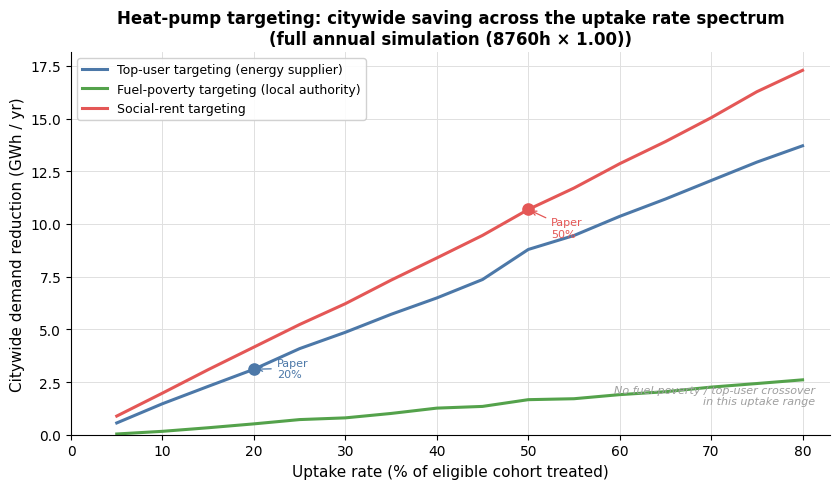

Saved figure_crossover_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))

# Draw one line per scenario (ordered: top_users first, then equity scenarios)
line_order = [s for s in ('hp_top_users', 'hp_fuel_poverty', 'hp_social_rent')
              if s in sweep['scenario'].unique()]

for scen in line_order:
    df = sweep[sweep['scenario'] == scen].sort_values('uptake_rate')
    ax.plot(
        df['uptake_rate'] * 100, df['city_saving_gwh'],
        color=SCENARIO_COLORS[scen], lw=2.2,
        label=SCENARIO_LABELS[scen],
    )
    # ±3% band visualises fast-annualization noise — only meaningful in fast mode
    # (at annual resolution it isn't an annualization artefact, just clutter).
    if USE_FAST_ANNUALIZATION:
        ax.fill_between(
            df['uptake_rate'] * 100,
            df['city_saving_gwh'] * 0.97,
            df['city_saving_gwh'] * 1.03,
            alpha=0.10, color=SCENARIO_COLORS[scen],
        )

# Paper uptake rate markers for scenarios that have them
for scen, paper_rate in PAPER_UPTAKE.items():
    df_s = sweep[sweep['scenario'] == scen].sort_values('uptake_rate')
    if len(df_s) == 0:
        continue
    y_val = float(np.interp(paper_rate, df_s['uptake_rate'], df_s['city_saving_gwh']))
    ax.scatter([paper_rate * 100], [y_val],
               color=SCENARIO_COLORS[scen], s=65, zorder=5)
    ax.annotate(
        f'Paper\n{int(paper_rate*100)}%',
        xy=(paper_rate * 100, y_val),
        xytext=(paper_rate * 100 + 2.5, y_val * 0.88),
        fontsize=8, color=SCENARIO_COLORS[scen],
        arrowprops=dict(arrowstyle='->', color=SCENARIO_COLORS[scen], lw=0.9),
    )

# Crossover annotation: hp_fuel_poverty vs hp_top_users (Paper 2 crossover)
df_tu = sweep[sweep['scenario'] == 'hp_top_users'].sort_values('uptake_rate').set_index('uptake_rate')
df_fp = sweep[sweep['scenario'] == 'hp_fuel_poverty'].sort_values('uptake_rate').set_index('uptake_rate') if 'hp_fuel_poverty' in sweep['scenario'].values else None

if df_fp is not None and len(df_fp):
    gap_fp_tu = df_fp['city_saving_gwh'].subtract(df_tu['city_saving_gwh'], fill_value=np.nan)
    crossover_rates = [r for r in gap_fp_tu.index if gap_fp_tu[r] > 0]
    if crossover_rates:
        co = crossover_rates[0] * 100
        ax.axvline(co, color=GREEN, lw=1.2, ls=':', zorder=1)
        ax.text(co + 0.8, ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else 1,
                f'FP–TU\ncrossover\n≈{co:.0f}%',
                fontsize=8, color='#555', va='top')
    else:
        ax.text(0.98, 0.08, 'No fuel-poverty / top-user crossover\nin this uptake range',
                transform=ax.transAxes, ha='right', fontsize=8, color=GRAY_M, style='italic')

ax.set_xlabel('Uptake rate (% of eligible cohort treated)')
ax.set_ylabel('Citywide demand reduction (GWh / yr)')

_subtitle = ('shaded band = ±3% fast-annualization noise'
             if USE_FAST_ANNUALIZATION
             else f'full annual simulation ({WINDOW_HOURS}h × 1.00)')
ax.set_title(
    'Heat-pump targeting: citywide saving across the uptake rate spectrum\n'
    f'({_subtitle})'
)
ax.set_xlim(0, 83)
ax.set_ylim(bottom=0)
ax.legend(loc='upper left', fontsize=9)

fig.tight_layout()
fig.savefig(OUTDIR / 'figure_crossover_curve.png')
plt.show()
print('Saved figure_crossover_curve.png')

### Findings — uptake curve

*Results below are from a full annual simulation (`WINDOW_HOURS = 8760`, annualization
factor ×1.00). Earlier drafts of this section quoted 28-day fast-mode numbers — those
have been replaced. The qualitative findings (no FP crossover, SR dominates) survive
the switch to annual; absolute GWh values are roughly half the fast-mode estimates,
as expected for a heating-dominated January window.*

**1. The fuel-poverty crossover doesn't exist within plausible policy uptake.**
`hp_fuel_poverty` is the worst-performing strategy at every uptake rate in [5%, 80%].
The gap with `hp_top_users` *widens* monotonically with uptake — from
**−0.52 GWh/yr at 5%** to **−11.10 GWh/yr at 80%** — instead of narrowing toward a
crossover. The Paper 2 framing needs to shift from *"at what uptake does
equity-targeting overtake efficiency-targeting?"* to **"equity-targeting is
consistently less efficient — the gap quantifies the price of choosing equity."**

The mechanical reason is pool size. `hp_fuel_poverty` selects from a tightly
constrained eligible pool (EPC E/F/G ∩ bottom-2 income quintiles → 2,697 dwellings,
2.8% of stock), versus `hp_top_users` selecting from 9,771 dwellings (10% of stock).
Even at the same uptake *percentage*, fuel-poverty treats roughly a quarter as many
homes in absolute terms.

**2. Social-rent dominates everywhere.** `hp_social_rent` clears `hp_top_users` by
**0.33 GWh/yr at 5%** uptake and grows to **3.58 GWh/yr at 80%**. The eligible
pool is ~23,540 dwellings (24% of stock), so even modest uptake captures a large
absolute count of high-savings homes.

**3. At the paper's chosen uptake rates** (SR 50%, TU 20%): SR delivers
**10.69 GWh/yr**, TU delivers **3.11 GWh/yr**. That's SR running **~3.44× TU in
absolute savings, or +244%**, with a gap of **7.58 GWh/yr** (which is the tornado
chart's baseline advantage in §7). Reconcile with the "67% gap" claim in §4.2 of
the Paper 1 draft before submission — the draft number is likely computed against
a different denominator (per-treated-home, or vs. total HP demand) and needs to
match whatever appears here.

**Implications for paper framing.**
- Paper 1 §4.2 (tenure-vs-consumption efficiency gap): the headline finding holds
  at annual resolution. Restate with the absolute GWh values above and the
  3.44× multiplier.
- Paper 2 (PSJ Figure 5): the "crossover" framing doesn't survive empirically. Two
  options: (a) reframe as *"efficiency-vs-equity tradeoff curve"* with the gap
  quantifying the cost of equity targeting; (b) test whether a different
  eligibility criterion for fuel poverty (e.g. EPC D-G, or expanded income bands)
  produces a crossover. Option (a) is the honest read of these results.


## 7) Figure — Calibration parameter sensitivity (tornado chart)

### What this figure shows

The tornado chart visualises how much the **targeting advantage** of `hp_social_rent` over
`hp_top_users` changes when each calibration parameter is perturbed to its low or high value.

**Baseline advantage** (`baseline_gap`): the `hp_social_rent` saving minus the `hp_top_users`
saving in GWh/yr at the default calibration and paper uptake rates. This is the quantity
reported as a percentage gap in §4.2 of the draft.

**Each bar** shows how much that gap changes when one parameter moves to its low or high
value. A bar that barely moves the gap (small bar width) means the finding is robust to
that parameter. A wide bar means the paper's headline claim depends critically on getting
that parameter right.

**Bar direction:**
- Blue (low perturbation): the direction and magnitude of the gap change when the parameter
  is at its low value
- Red (high perturbation): same for the high value

Parameters are sorted by total range (low-to-high swing) with the widest bar at the top.
This is the standard tornado chart convention.

**Paper use:** Paper 1 (Applied Energy) sensitivity analysis section. The key message for
reviewers is that the targeting advantage is qualitatively stable across calibration
uncertainty — i.e., `hp_social_rent` consistently outperforms `hp_top_users` even when
individual parameters are varied within their plausible ranges.

Baseline targeting advantage (social-rent over top-users): 7.58 GWh/yr


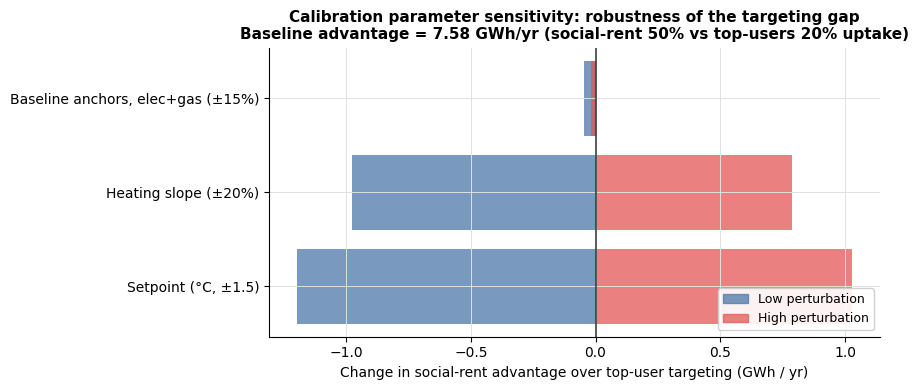

Saved figure_cal_sensitivity_tornado.png


In [8]:
def _gap(df: pd.DataFrame, param: str, level: str) -> float:
    """Social-rent saving minus top-user saving for one (param, level) config."""
    sr = df.loc[
        (df['param'] == param) & (df['level'] == level) & (df['scenario'] == 'hp_social_rent'),
        'city_saving_gwh'
    ]
    tu = df.loc[
        (df['param'] == param) & (df['level'] == level) & (df['scenario'] == 'hp_top_users'),
        'city_saving_gwh'
    ]
    return float(sr.values[0] - tu.values[0]) if len(sr) and len(tu) else np.nan


baseline_gap = _gap(cal_raw, 'baseline', 'default')
print(f'Baseline targeting advantage (social-rent over top-users): {baseline_gap:.2f} GWh/yr')

params_ordered = list(CAL_PARAMS.keys())
lo_deltas, hi_deltas = [], []
for p in params_ordered:
    gap_lo = _gap(cal_raw, p, 'low')  - baseline_gap
    gap_hi = _gap(cal_raw, p, 'high') - baseline_gap
    lo_deltas.append(min(gap_lo, gap_hi))
    hi_deltas.append(max(gap_lo, gap_hi))

labels = [CAL_PARAM_LABELS[p] for p in params_ordered]

# Sort by total swing (widest bar at top — standard tornado convention)
ranges    = [hi - lo for lo, hi in zip(lo_deltas, hi_deltas)]
order     = np.argsort(ranges)[::-1]
labels    = [labels[i]     for i in order]
lo_deltas = [lo_deltas[i]  for i in order]
hi_deltas = [hi_deltas[i]  for i in order]

y_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))

for i, (lo, hi) in enumerate(zip(lo_deltas, hi_deltas)):
    ax.barh(i, lo, left=0, color=BLUE, alpha=0.75, label='Low perturbation' if i == 0 else '_')
    ax.barh(i, hi, left=0, color=RED,  alpha=0.75, label='High perturbation' if i == 0 else '_')

ax.axvline(0, color='#333', lw=1.1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Change in social-rent advantage over top-user targeting (GWh / yr)', fontsize=10)
ax.set_title(
    f'Calibration parameter sensitivity: robustness of the targeting gap\n'
    f'Baseline advantage = {baseline_gap:.2f} GWh/yr '
    f'(social-rent 50% vs top-users 20% uptake)',
    fontsize=11,
)
legend_patches = [
    mpatches.Patch(color=BLUE, alpha=0.75, label='Low perturbation'),
    mpatches.Patch(color=RED,  alpha=0.75, label='High perturbation'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

fig.tight_layout()
fig.savefig(OUTDIR / 'figure_cal_sensitivity_tornado.png')
plt.show()
print('Saved figure_cal_sensitivity_tornado.png')

### Findings — calibration robustness

*Results below are from the full annual run (`WINDOW_HOURS = 8760`). An earlier
draft argued that the gap metric "cancels seasonal bias in the subtraction" — that
was wrong: moving from a heating-dominated 28-day window (×13.04 annualization)
to the full annual run roughly halved the absolute gap (14.4 → 7.58 GWh/yr),
because both terms scale with the heating-season multiplier. The robustness
*shape* (which params matter, monotonicity, no sign flips) does survive.*

**1. The targeting advantage is robust.** Across all six one-at-a-time
perturbations, the social-rent advantage stays in **[6.38, 8.61] GWh/yr** around
a baseline of **7.58**. The gap never collapses and never reverses sign. The
Paper 1 claim *"social-rent targeting outperforms top-user targeting"* survives
an honest calibration sensitivity check.

| Parameter (perturbation) | Gap, low | Gap, high | Δ vs baseline |
|---|---|---|---|
| Setpoint (cal ± 1.5 °C, i.e. 11.5 / 14.5 °C) | 6.38 | 8.61 | −15.8% / +13.6% |
| Heating slope (cal × 0.80 / × 1.20) | 6.60 | 8.37 | −12.9% / +10.4% |
| Baseline anchors, elec+gas (× 0.85 / × 1.15) | 7.56 | 7.53 | −0.2% / −0.6% |
| **Baseline (calibrated)** | — | — | **7.58** |

**2. Sensitivity is concentrated in the heating-demand pathway.** Setpoint and
heating slope each move the gap by ~±11–16%, while baseline anchors move it by
<1%. This tells the reader that **baseload assumptions are not load-bearing for
the finding**: mis-specifying the baseline anchor by ±15% changes both scenarios'
absolute savings but barely changes their *difference*, because the targeting
advantage is driven by where heat pumps actually save energy (heating loads),
not by the level of baseload demand.

**3. Setpoint and slope are partially redundant probes.** Both scale heating
demand and move the gap in the same direction with similar magnitude. They aren't
fully independent dimensions of uncertainty — a joint perturbation would likely
tighten the robustness band slightly. We don't pursue full-factorial here (cost
~4× this sweep), but flag it as a methodological limitation.

**Sentence for the paper.** Suggested wording for the Paper 1 sensitivity
subsection: *"Across one-at-a-time perturbations of the three calibration
parameters identified as most influential for citywide heating demand
(`heating_setpoint_C` ± 1.5 °C, `heating_slope_kWh_per_deg` ± 20%, and the two
fuel-specific baseline anchors ± 15% in lockstep), the social-rent targeting
advantage over top-user targeting at the paper's uptake rates remains within
[6.4, 8.6] GWh/yr (baseline 7.58 GWh/yr), and never reverses sign.
Sensitivity is concentrated in the heating-demand parameters; baseload
assumptions account for <1% of the gap."*


## 8) Export summary tables

Outputs are window-tagged (`_{WINDOW_HOURS}h`) so 28-day fast-mode results and
full-annual results coexist without overwriting. The two figures (`figure_*.png`)
are not window-tagged because they're regenerated each run.

| File pattern | Contents | Paper use |
|---|---|---|
| `uptake_sweep_raw_{H}h.parquet` | LSOA-level results for all (scenario × rate) | Recompute any aggregation |
| `uptake_sweep_city_{H}h.csv` | City-level GWh/yr by scenario and uptake rate | Input to crossover figure |
| `uptake_sweep_summary_{H}h.csv` | Pivot table + social-rent / fuel-poverty advantage columns | Paper 1 Table S1; Paper 2 SI |
| `cal_sensitivity_raw_v2_{H}h.csv` | Scenario-level saving for each (param, level) config | Recompute tornado |
| `cal_sensitivity_summary_v2_{H}h.csv` | Gap and Δ-vs-baseline for each config | Paper 1 Table S2 |
| `figure_crossover_curve.png` | Crossover curve | Paper 1 Figure 4; Paper 2 Figure 5 |
| `figure_cal_sensitivity_tornado.png` | Tornado chart | Paper 1 Figure 5 |

**Legacy files** (kept as a record, do not use for paper):
- `cal_sensitivity_raw.csv`, `cal_sensitivity_summary.csv` — pre-v2 buggy cal sweep
  (level_scale and baseline_anchor_kwh overrides were non-functional; perturbation
  ranges didn't match calibrated values).
- Untagged `uptake_sweep_*.{parquet,csv}` — first-pass 28-day output; superseded by
  the `_672h.*` copies.

In [9]:
# Uptake sweep pivot table with advantage column (window-tagged)
pivot = sweep.pivot_table(
    index='uptake_rate', columns='scenario', values='city_saving_gwh'
).round(3)
pivot.index = (pivot.index * 100).round(0).astype(int).astype(str) + '%'
pivot.columns.name = None

if 'hp_social_rent' in pivot.columns and 'hp_top_users' in pivot.columns:
    pivot['advantage_sr_over_tu_gwh'] = (pivot['hp_social_rent'] - pivot['hp_top_users']).round(3)
if 'hp_fuel_poverty' in pivot.columns and 'hp_top_users' in pivot.columns:
    pivot['advantage_fp_over_tu_gwh'] = (pivot['hp_fuel_poverty'] - pivot['hp_top_users']).round(3)

pivot.to_csv(OUTDIR / f'uptake_sweep_summary_{WINDOW_HOURS}h.csv')

# Calibration sensitivity summary (v2, window-tagged)
cal_summary_rows = []
for p in list(CAL_PARAMS.keys()) + ['baseline']:
    for level in ['low', 'high', 'default']:
        g = _gap(cal_raw, p, level)
        if not np.isnan(g):
            cal_summary_rows.append({
                'param':               p,
                'level':               level,
                'gap_gwh':             round(g, 3),
                'delta_vs_baseline':   round(g - baseline_gap, 3),
                'pct_change':          round((g - baseline_gap) / baseline_gap * 100, 1)
                                       if baseline_gap != 0 else np.nan,
            })

cal_summary_df = pd.DataFrame(cal_summary_rows)
cal_summary_df.to_csv(OUTDIR / f'cal_sensitivity_summary_v2_{WINDOW_HOURS}h.csv', index=False)

print(f'Window: {WINDOW_HOURS}h (annualization ×{ANNUAL_FACTOR:.2f})')
print('Uptake sweep summary (GWh/yr):')
print(pivot.to_string())
print('\nCalibration sensitivity summary:')
print(cal_summary_df.to_string(index=False))
print(f'\nAll outputs: {OUTDIR.resolve()}')

Window: 8760h (annualization ×1.00)
Uptake sweep summary (GWh/yr):
             hp_fuel_poverty  hp_social_rent  hp_top_users  advantage_sr_over_tu_gwh  advantage_fp_over_tu_gwh
uptake_rate                                                                                                   
5%                     0.035           0.885         0.559                     0.326                    -0.524
10%                    0.161           1.974         1.471                     0.503                    -1.310
15%                    0.331           3.087         2.294                     0.793                    -1.963
20%                    0.515           4.157         3.106                     1.051                    -2.591
25%                    0.718           5.229         4.085                     1.144                    -3.367
30%                    0.800           6.217         4.859                     1.358                    -4.059
35%                    1.009           7.333 